Generating P-v Diagram for Water...


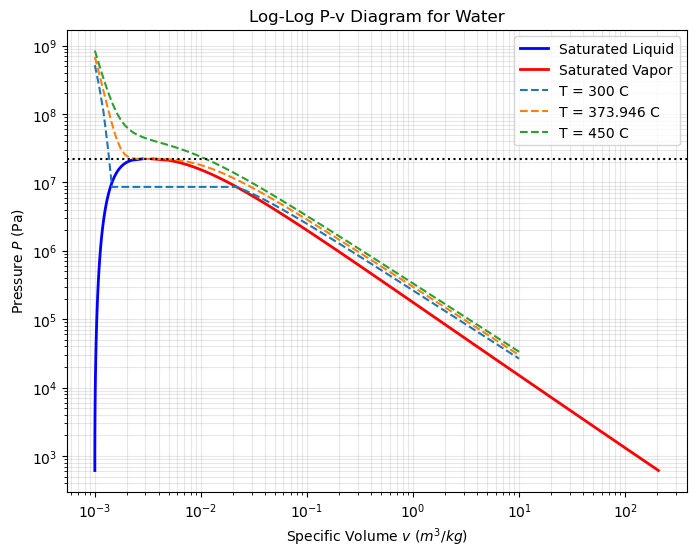

In [ ]:
# ==============================================================================
# LECTURE 4: Generating a PV phase diagram
# Script: PV-diagram
# Author: Edward Maginn, CBE 20260
# Description: 
#   This notebook lets you interactively generate PV phase diagrams for
#   various fluids using the CoolProp library.

# Tip: Run this notebook in Google Colab for easy access to CoolProp.
# Try changing the fluid name in the function call. Look
# up other fluid names in the CoolProp documentation:
# https://coolprop.org/fluid_properties/PurePseudoPure.html#list-of-fluids

# ==============================================================================

# Install CoolProp if running in Colab
try:
    import CoolProp
except ImportError:
    %pip install CoolProp
    print("CoolProp installed successfully.")
    
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_Pv_diagram(fluid='Water'):
    print(f"Generating P-v Diagram for {fluid}...")
    
    # 1. Get Critical Point Data
    T_crit = CP.PropsSI('Tcrit', fluid)
    P_crit = CP.PropsSI('Pcrit', fluid)
    
    # 2. Generate the Saturation Dome (Liquid and Vapor lines)
    # We span temperatures from Triple Point up to Critical Point
    T_min = CP.PropsSI('Tmin', fluid)
    T_vals = np.linspace(T_min, T_crit - 0.1, 100) # Stop just before critical point
    
    v_liq = []
    v_vap = []
    P_sat = []
    
    for T in T_vals:
        # Calculate Saturation Pressure at this T
        # Q is the quality of the fluid: 0 = saturated liquid, 1 = saturated vapor
        P = CP.PropsSI('P', 'T', T, 'Q', 0, fluid)
        P_sat.append(P)
        
        # Calculate Saturated Liquid Volume (Q=0)
        # v = 1 / density
        rho_l = CP.PropsSI('D', 'T', T, 'Q', 0, fluid)
        v_liq.append(1/rho_l)
        
        # Calculate Saturated Vapor Volume (Q=1)
        rho_v = CP.PropsSI('D', 'T', T, 'Q', 1, fluid)
        v_vap.append(1/rho_v)
        
    # 3. Generate Isotherms (Constant Temperature lines)
    # Let's plot 3 isotherms: One below crit, one at crit, one above
    # These temperatures are for water; adjust for other fluids as needed
    isotherms_C = [300, 373.946, 450] # Temperatures in Celsius
    # (Note: Water T_crit is approx 373.946 C)
    
    plt.figure(figsize=(8, 6))
    
    # Plot Dome
    plt.plot(v_liq, P_sat, 'b-', label='Saturated Liquid', lw=2)
    plt.plot(v_vap, P_sat, 'r-', label='Saturated Vapor', lw=2)
    
    # Plot Isotherms
    v_iso = np.logspace(-3, 1, 100) # Log spacing for volume is better
    
    for T_c in isotherms_C:
        T_k = T_c + 273.15
        P_iso = []
        for v in v_iso:
            try:
                # Calculate P given T and v (Density)
                p_val = CP.PropsSI('P', 'T', T_k, 'D', 1/v, fluid)
                P_iso.append(p_val)
            except:
                P_iso.append(None)
        
        plt.plot(v_iso, P_iso, '--', label=f'T = {T_c} C')

    # Formatting to match textbook style
    plt.xscale('log') # Crucial for P-v diagrams
    plt.yscale('log')
    plt.xlabel('Specific Volume $v$ ($m^3/kg$)')
    plt.ylabel('Pressure $P$ (Pa)')
    plt.title(f'Log-Log P-v Diagram for {fluid}')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    plt.axhline(P_crit, color='k', linestyle=':', label='Critical Pressure')
    
    plt.show()

# Run the function
plot_Pv_diagram('Water')